In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import pickle
import os
from sklearn.decomposition import PCA





In [3]:
mobile =pd.read_csv("Mobile Reviews Sentiment null.csv")
print (mobile.info())
print (mobile.describe())
print (mobile.isnull().sum())
print (mobile.shape)

mobile.head()


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  str    
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  str    
 4   model                 50000 non-null  str    
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  str    
 7   currency              50000 non-null  str    
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  str    
 11  country               50000 non-null  str    
 12  language              50000 non-null  str    
 13  review_date           50000 non-null  str    
 14  verified_purchase     50000 non-null  bool   
 15  battery_life_rating   50000 no

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [4]:
mobile.drop(columns=["price_local"], inplace=True)
mobile.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                  2448
dtype: int64

In [5]:
mobile

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2.0,Negative,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4.0,Positive,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4.0,Positive,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3.0,Positive,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3.0,Neutral,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,AUD,1.53,4.0,Positive,...,English,8/17/2023,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,AUD,1.53,3.0,Neutral,...,English,9/23/2023,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,AED,3.67,NaN,Positive,...,English,4/4/2023,True,2,3,4,4,5,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,USD,1.00,3.0,Positive,...,English,7/11/2025,True,1,2,2,1,3,6,NaN


In [6]:
mobile['source'] = mobile['source'].fillna('store')
mobile['source'].isnull().sum()
mobile.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
currency                   0
exchange_rate_to_usd       0
rating                  2453
sentiment               2445
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
dtype: int64

In [7]:
mobile ['sentiment'].value_counts()

sentiment
Positive    26282
Neutral     11931
Negative     9342
Name: count, dtype: int64

In [8]:
mobile.groupby('sentiment')['rating'].mean()

sentiment
Negative    1.608102
Neutral     2.486651
Positive    3.957511
Name: rating, dtype: float64

## updating rating according to  sentiment  fills nulls using sentiment group median

In [9]:
mobile['rating'] = mobile.groupby('sentiment')['rating'].transform(lambda x: x.fillna(x.median()))
mobile['rating'] = mobile['rating'].fillna(mobile['rating'].median())
mobile['rating'] = mobile['rating'].round().astype(int)
mobile['rating'].isnull().sum()

np.int64(0)

## Rating and sentiment has some core relation so adding it 

In [10]:
def fill_sentiment(row):
    if pd.isnull(row['sentiment']):
        if row['rating'] <= 2:
            return 'Negative'
        elif row['rating'] == 3:
            return 'Neutral'
        else:
            return 'Positive'
    return row['sentiment']

mobile['sentiment'] = mobile.apply(fill_sentiment, axis=1)
mobile.isnull().sum()

review_id                  0
customer_name              0
age                        0
brand                      0
model                      0
price_usd               2450
currency                   0
exchange_rate_to_usd       0
rating                     0
sentiment                  0
country                    0
language                   0
review_date                0
verified_purchase          0
battery_life_rating        0
camera_rating              0
performance_rating         0
design_rating              0
display_rating             0
helpful_votes              0
source                     0
dtype: int64

In [11]:
mobile.dropna(subset=['price_usd'], inplace=True)
mobile['price_usd'].isnull().sum()

np.int64(0)

In [12]:
mobile.duplicated().sum()

np.int64(0)

In [13]:
mobile

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2,Negative,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4,Positive,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4,Positive,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3,Positive,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3,Neutral,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,AUD,1.53,4,Positive,...,English,8/17/2023,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,AUD,1.53,3,Neutral,...,English,9/23/2023,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,AED,3.67,4,Positive,...,English,4/4/2023,True,2,3,4,4,5,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,USD,1.00,3,Positive,...,English,7/11/2025,True,1,2,2,1,3,6,store


## outliers  handling 

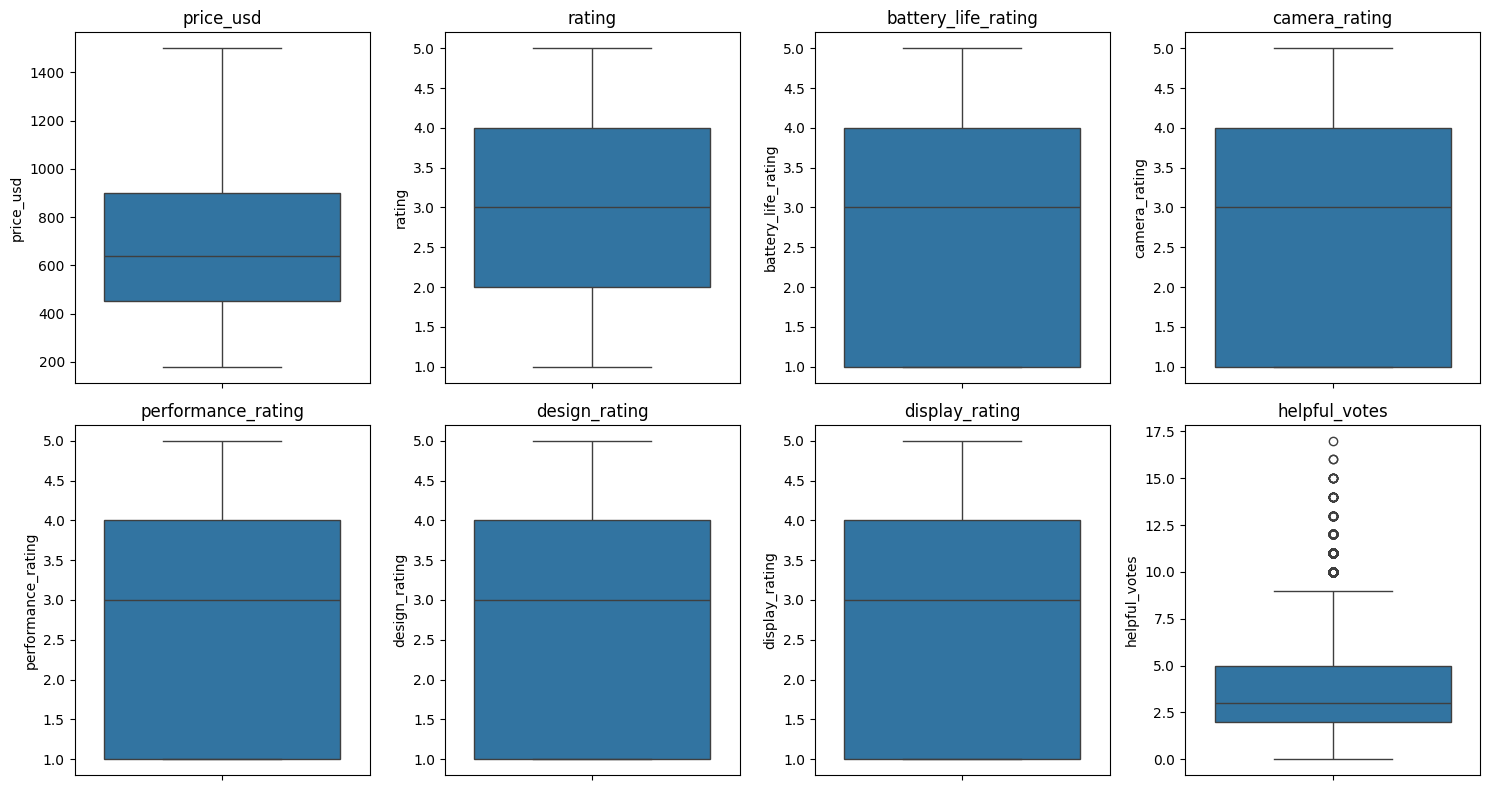

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating', 
           'performance_rating', 'design_rating', 'display_rating', 'helpful_votes']

plt.figure(figsize=(15, 8))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=mobile[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [15]:
for col in columns:
    Q1 = mobile[col].quantile(0.25)
    Q3 = mobile[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = mobile[(mobile[col] < lower) | (mobile[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | lower bound: {lower:.2f} | upper bound: {upper:.2f}")

price_usd: 0 outliers | lower bound: -225.30 | upper bound: 1577.51
rating: 0 outliers | lower bound: -1.00 | upper bound: 7.00
battery_life_rating: 0 outliers | lower bound: -3.50 | upper bound: 8.50
camera_rating: 0 outliers | lower bound: -3.50 | upper bound: 8.50
performance_rating: 0 outliers | lower bound: -3.50 | upper bound: 8.50
design_rating: 0 outliers | lower bound: -3.50 | upper bound: 8.50
display_rating: 0 outliers | lower bound: -3.50 | upper bound: 8.50
helpful_votes: 863 outliers | lower bound: -2.50 | upper bound: 9.50


In [16]:
mobile["helpful_votes"]=mobile['helpful_votes'].clip(upper=9)
print("Max helpful_votes after capping:", mobile['helpful_votes'].max())

Max helpful_votes after capping: 9


## Handled outliers and after caping helpful voters 

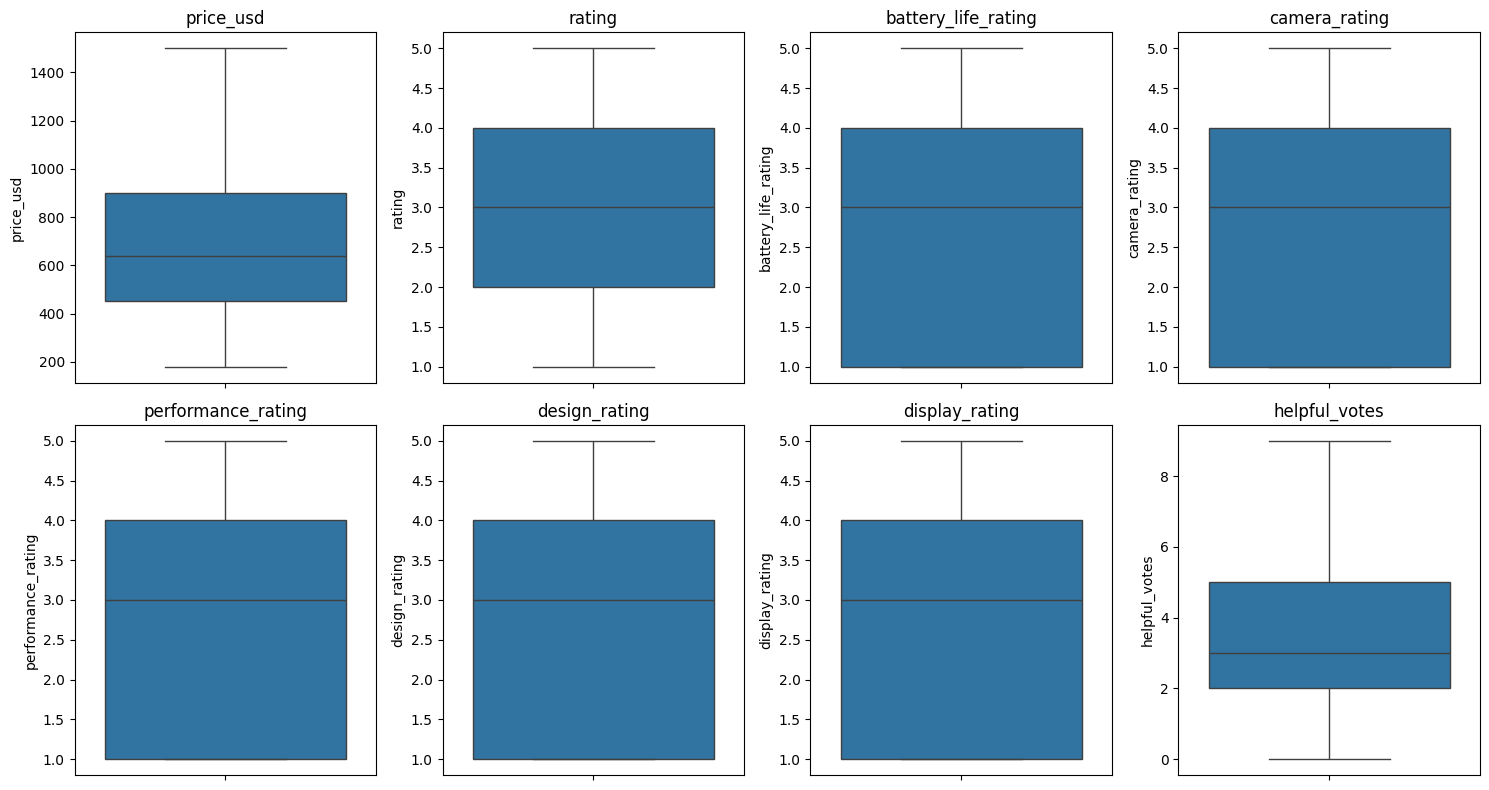

In [17]:
columns = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating', 
           'performance_rating', 'design_rating', 'display_rating', 'helpful_votes']

plt.figure(figsize=(15, 8))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=mobile[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [18]:
mobile.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
review_id,47550.0,24996.659516,14440.669750,1.00,12471.250,24979.500,37525.7500,50000.00
age,47550.0,30.073249,8.934499,18.00,23.000,29.000,36.0000,65.00
price_usd,47550.0,689.892770,310.327220,180.02,450.755,637.585,901.4575,1499.89
exchange_rate_to_usd,47550.0,12.045131,26.535071,0.78,1.000,1.530,5.7000,83.00
rating,47550.0,3.111356,1.219443,1.00,2.000,3.000,4.0000,5.00
battery_life_rating,47550.0,2.720736,1.347635,1.00,1.000,3.000,4.0000,5.00
camera_rating,47550.0,2.717624,1.343813,1.00,1.000,3.000,4.0000,5.00
performance_rating,47550.0,2.719579,1.349290,1.00,1.000,3.000,4.0000,5.00
design_rating,47550.0,2.713649,1.343684,1.00,1.000,3.000,4.0000,5.00
display_rating,47550.0,2.721283,1.352095,1.00,1.000,3.000,4.0000,5.00


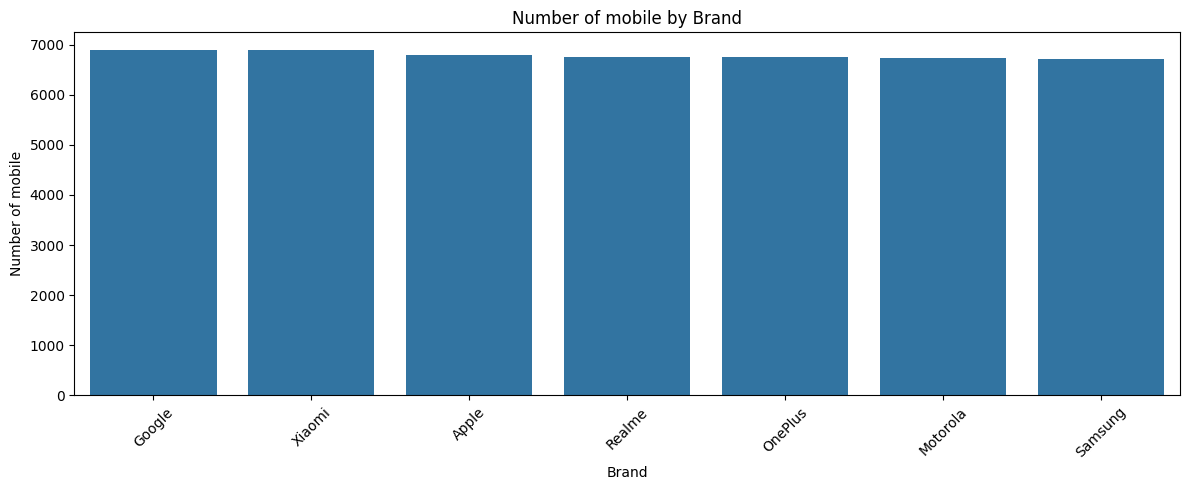

In [19]:
plt.figure(figsize=(12, 5))
brand_counts = mobile['brand'].value_counts()
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.title('Number of mobile by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of mobile')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

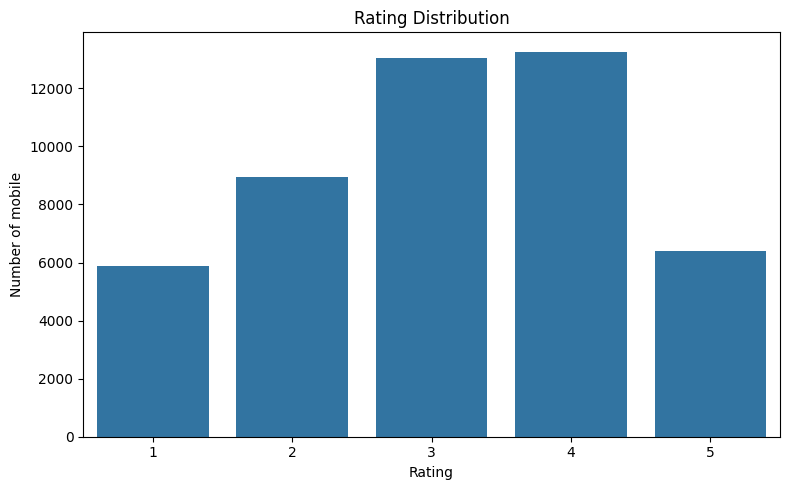

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x=mobile['rating'])
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of mobile')
plt.tight_layout()
plt.show()

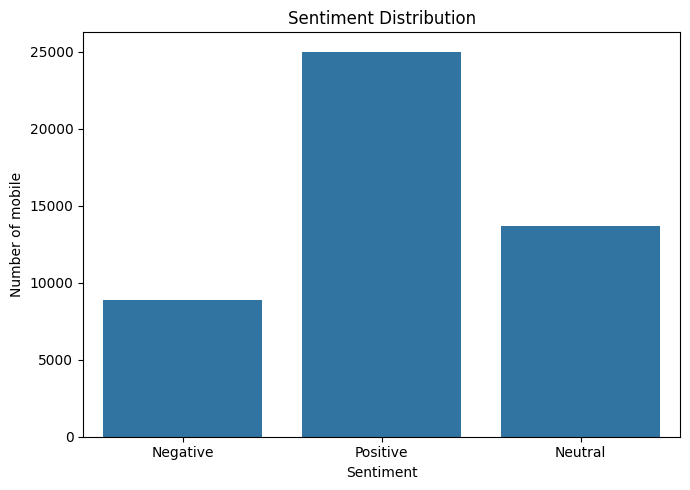

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(x=mobile['sentiment'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of mobile')
plt.tight_layout()
plt.show()

##  chart for brand and rating  

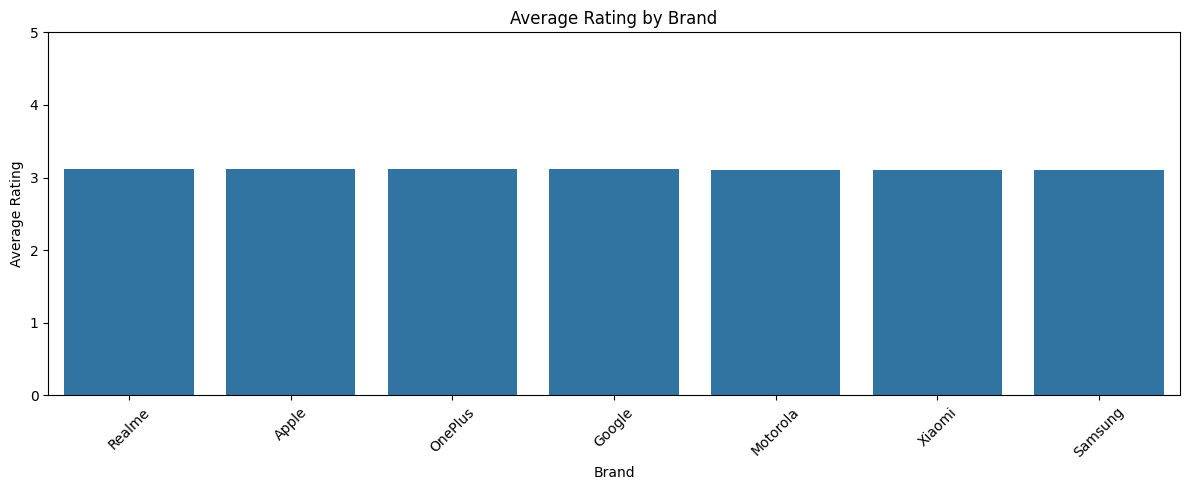

In [22]:
plt.figure(figsize=(12, 5))
brand_rating = mobile.groupby('brand')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=brand_rating.index, y=brand_rating.values)
plt.title('Average Rating by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### chart for brand and price

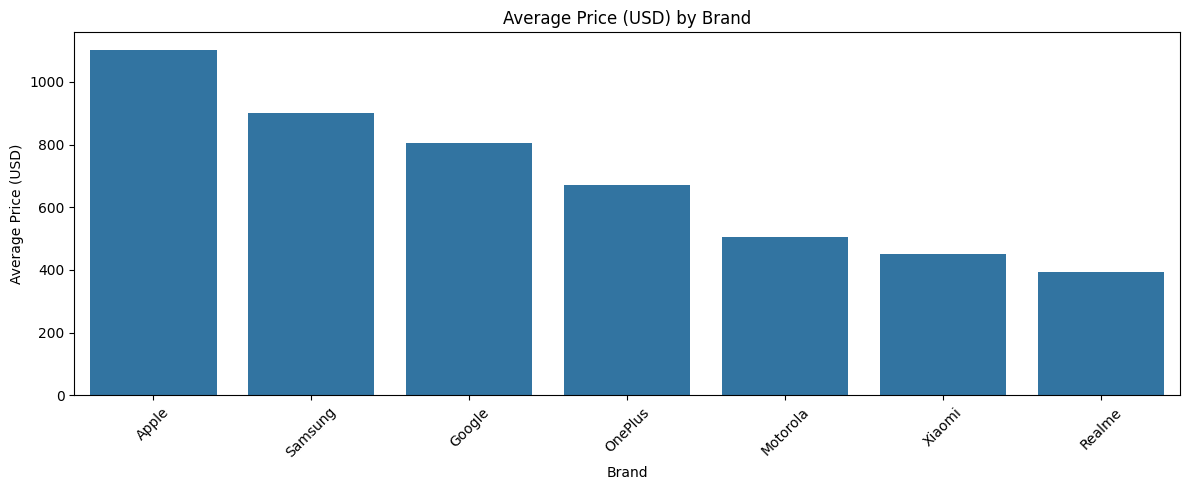

In [23]:
plt.figure(figsize=(12, 5))
brand_price = mobile.groupby('brand')['price_usd'].mean().sort_values(ascending=False)
sns.barplot(x=brand_price.index, y=brand_price.values)
plt.title('Average Price (USD) by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Chart for  brand and country  with high   sale  

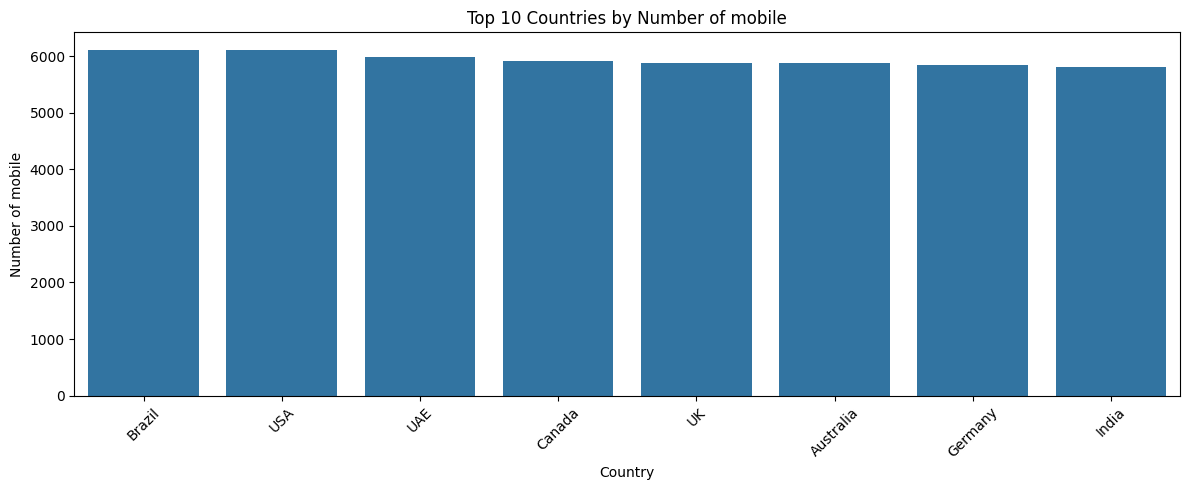

In [24]:
plt.figure(figsize=(12, 5))
country_counts = mobile['country'].value_counts().head(10)
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Top 10 Countries by Number of mobile')
plt.xlabel('Country')
plt.ylabel('Number of mobile')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### country that use what source in high  

<Figure size 1200x500 with 0 Axes>

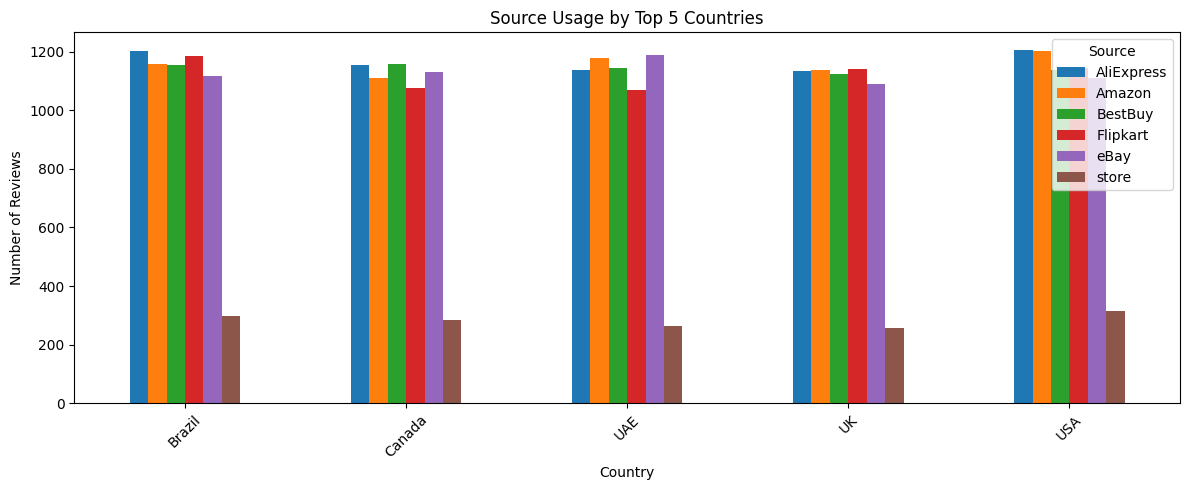

In [25]:
top_countries = mobile['country'].value_counts().head(5).index
filtered = mobile[mobile['country'].isin(top_countries)]

plt.figure(figsize=(12, 5))
source_country = filtered.groupby(['country', 'source']).size().unstack(fill_value=0)
source_country.plot(kind='bar', figsize=(12, 5))
plt.title('Source Usage by Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Source')
plt.tight_layout()
plt.show()

### verified_purchase has true  and false so i need the true sentiment and false sentiment

<Figure size 1000x500 with 0 Axes>

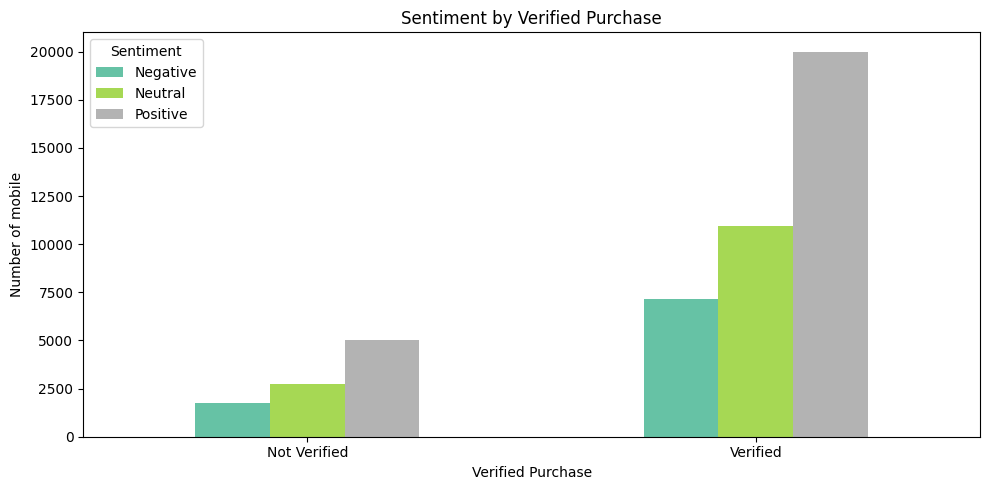

In [26]:
plt.figure(figsize=(10, 5))
verified_sentiment = mobile.groupby(['verified_purchase', 'sentiment']).size().unstack(fill_value=0)
verified_sentiment.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Sentiment by Verified Purchase')
plt.xlabel('Verified Purchase')
plt.ylabel('Number of mobile')
plt.xticks(ticks=[0, 1], labels=['Not Verified', 'Verified'], rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

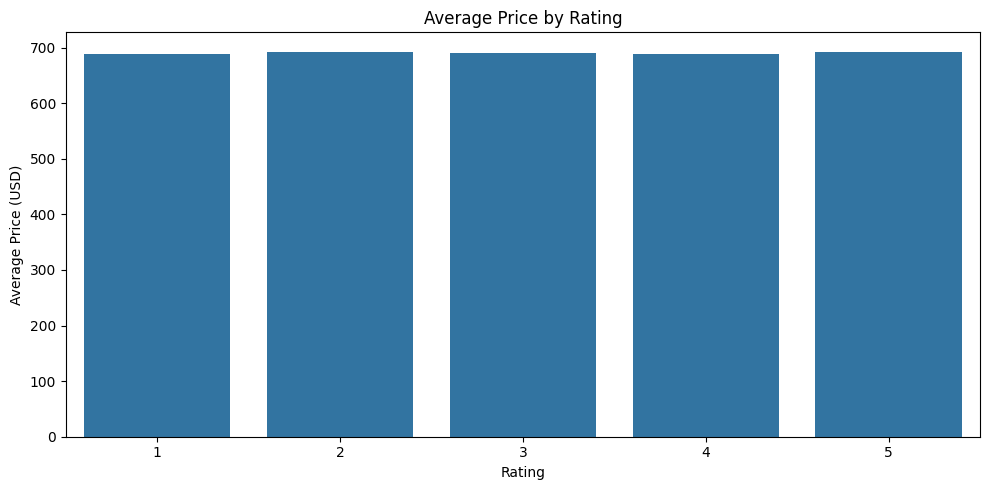

In [27]:
plt.figure(figsize=(10, 5))
avg_price_rating = mobile.groupby('rating')['price_usd'].mean()
sns.barplot(x=avg_price_rating.index, y=avg_price_rating.values)
plt.title('Average Price by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Price (USD)')
plt.tight_layout()
plt.show()

### Checking the core realiton with heat map  and 

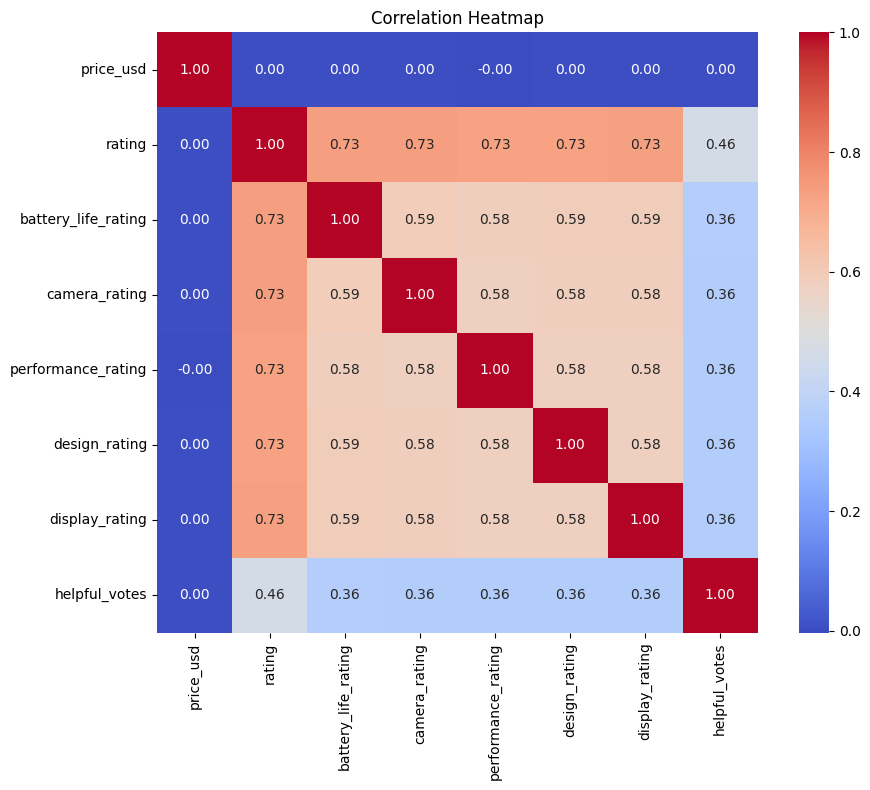

In [28]:
plt.figure(figsize=(10, 8))
numeric_cols = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating',
                'performance_rating', 'design_rating', 'display_rating', 'helpful_votes']

correlation = mobile[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Price has NO relationship with ratings
# and rating has relation with sub rating 
# helpful_votes has les reating with  other rating and sub rating 

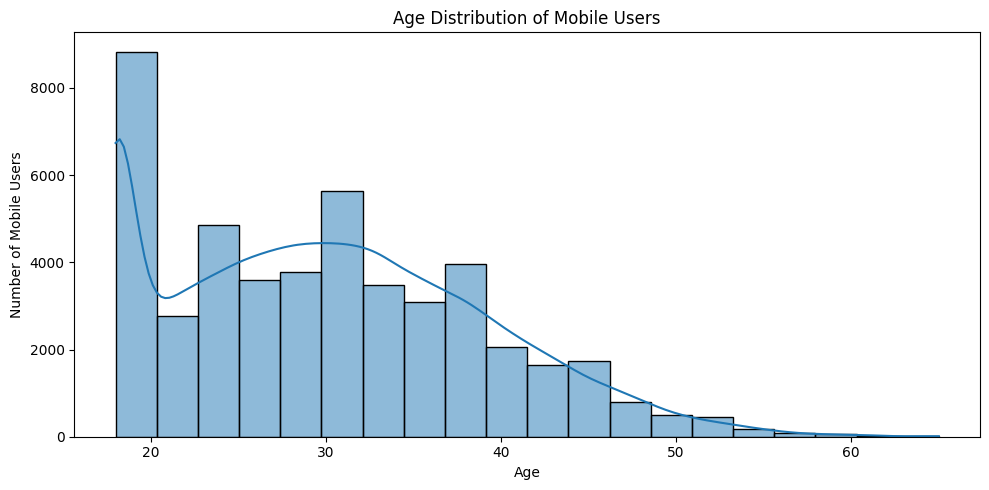

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(mobile['age'], bins=20, kde=True)
plt.title('Age Distribution of Mobile Users')
plt.xlabel('Age')
plt.ylabel('Number of Mobile Users')
plt.tight_layout()
plt.show()

In [30]:
mobile

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2,Negative,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4,Positive,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4,Positive,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3,Positive,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3,Neutral,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,AUD,1.53,4,Positive,...,English,8/17/2023,False,3,3,4,3,5,4,BestBuy
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,AUD,1.53,3,Neutral,...,English,9/23/2023,False,3,2,4,1,3,2,AliExpress
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,AED,3.67,4,Positive,...,English,4/4/2023,True,2,3,4,4,5,4,Amazon
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,USD,1.00,3,Positive,...,English,7/11/2025,True,1,2,2,1,3,6,store


### Mostly the  reviews are provided by 18-22 wher teen and coll pp byt and share feed back , ade from 25-32or 34 ther is spike as it is 2026 there is many pple start review on the social media the raring and review incresed based on ths too  above 40+ it drecress as they are bussineds ppl as it is reduced they wont use theitr time mostly on review   to impreove rating need to focus on 1-34 age group 

# Price Distribution:

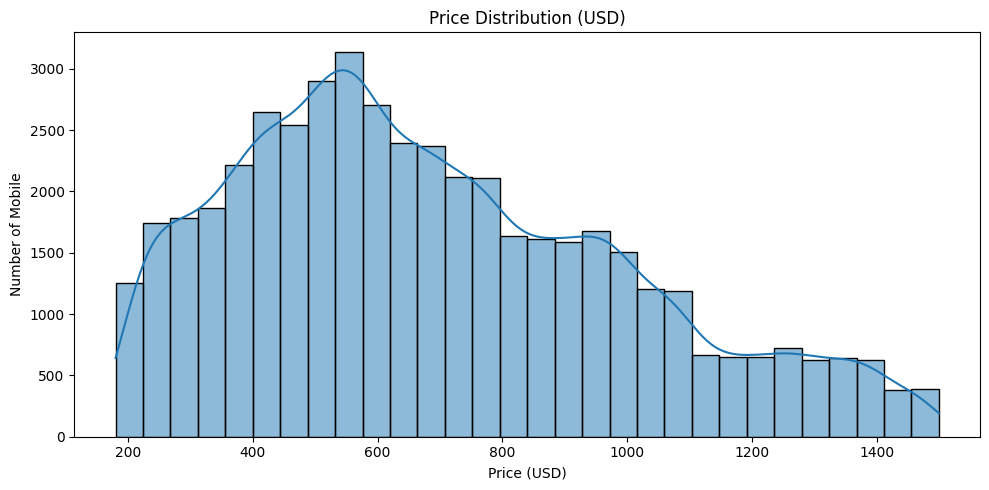

In [31]:
plt.figure(figsize=(10, 5))
sns.histplot(mobile['price_usd'], bins=30, kde=True)
plt.title('Price Distribution (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Number of Mobile')
plt.tight_layout()
plt.show()

### mid range of $400 - $800 is reviewed most as it has high market as mid range ppl afford it  and it s salse is high  review is also high 

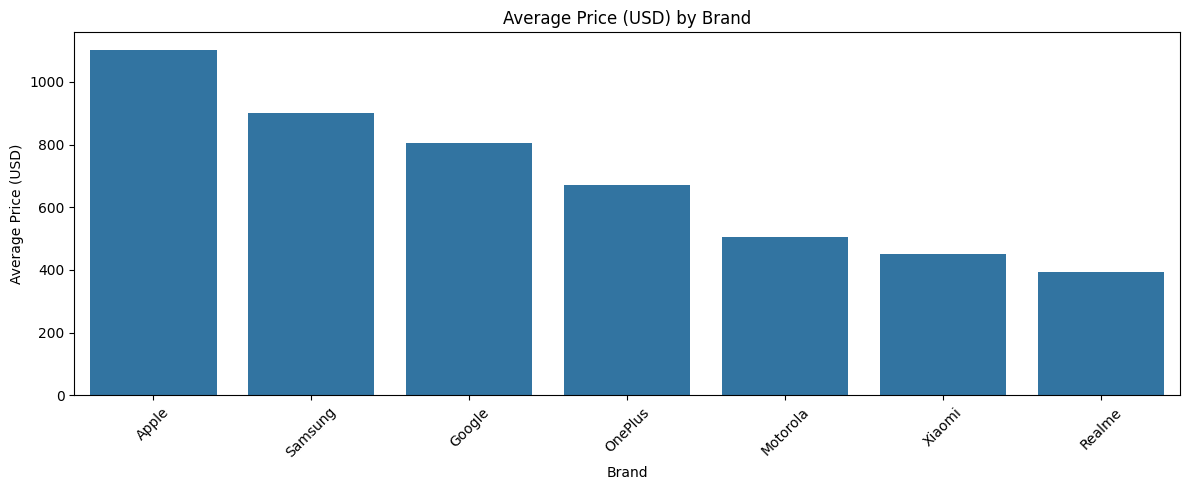

In [32]:
plt.figure(figsize=(12, 5))
brand_price = mobile.groupby('brand')['price_usd'].mean().sort_values(ascending=False)
sns.barplot(x=brand_price.index, y=brand_price.values)
plt.title('Average Price (USD) by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Clear 3 tiers visible:

Premium → Apple, Samsung, Google
Mid-range → OnePlus
Budget → Motorola, Xiaomi, Realme

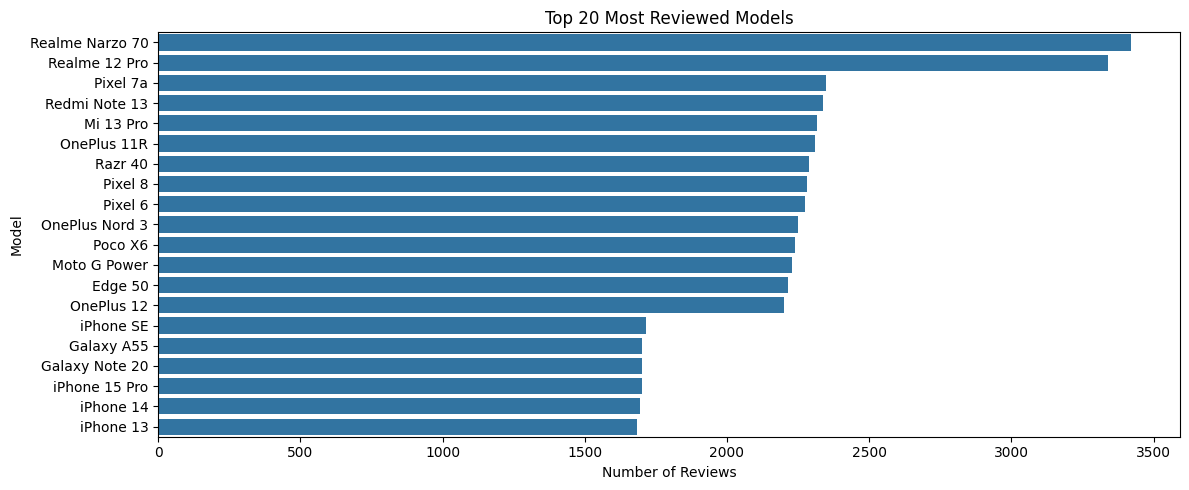

In [33]:
plt.figure(figsize=(12, 5))
model_counts = mobile['model'].value_counts().head(20)
sns.barplot(x=model_counts.values, y=model_counts.index)
plt.title('Top 20 Most Reviewed Models')
plt.xlabel('Number of Reviews')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

### Step 3 — Geographic Analysis:


<Figure size 1200x500 with 0 Axes>

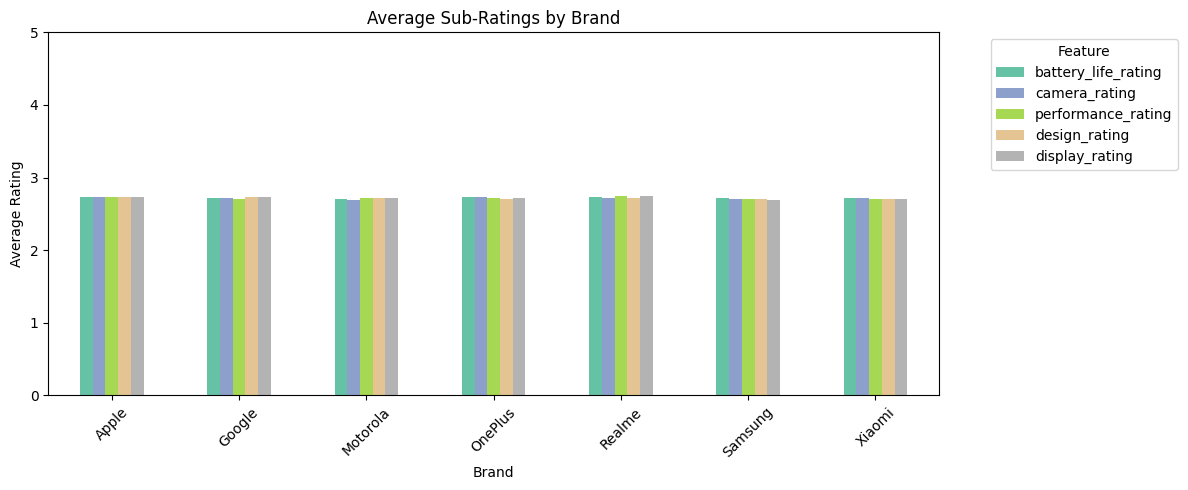

In [34]:
plt.figure(figsize=(12, 5))
sub_ratings = ['battery_life_rating', 'camera_rating', 'performance_rating', 
               'design_rating', 'display_rating']

brand_subratings = mobile.groupby('brand')[sub_ratings].mean()
brand_subratings.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Average Sub-Ratings by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Formatting the date

In [35]:
mobile['review_date'] = pd.to_datetime(mobile['review_date'], dayfirst=False, format='mixed')

print(mobile['review_date'].dtype)
print(mobile['review_date'].head(10))

datetime64[us]
0   2023-11-06
1   2023-03-30
2   2022-12-07
3   2025-03-11
4   2023-09-29
5   2023-06-27
6   2024-03-27
7   2024-04-08
8   2024-10-04
9   2025-02-25
Name: review_date, dtype: datetime64[us]


### finding Skewed detials 

In [36]:
numeric_cols = ['rating', 'price_usd', 'helpful_votes', 
                'battery_life_rating', 'camera_rating', 
                'performance_rating', 'design_rating', 'display_rating']

skewness = mobile[numeric_cols].skew()
print("Skewness of Numeric Columns:")
print(skewness)

Skewness of Numeric Columns:
rating                -0.178796
price_usd              0.559342
helpful_votes          0.492283
battery_life_rating    0.207080
camera_rating          0.205030
performance_rating     0.203734
design_rating          0.216035
display_rating         0.204144
dtype: float64


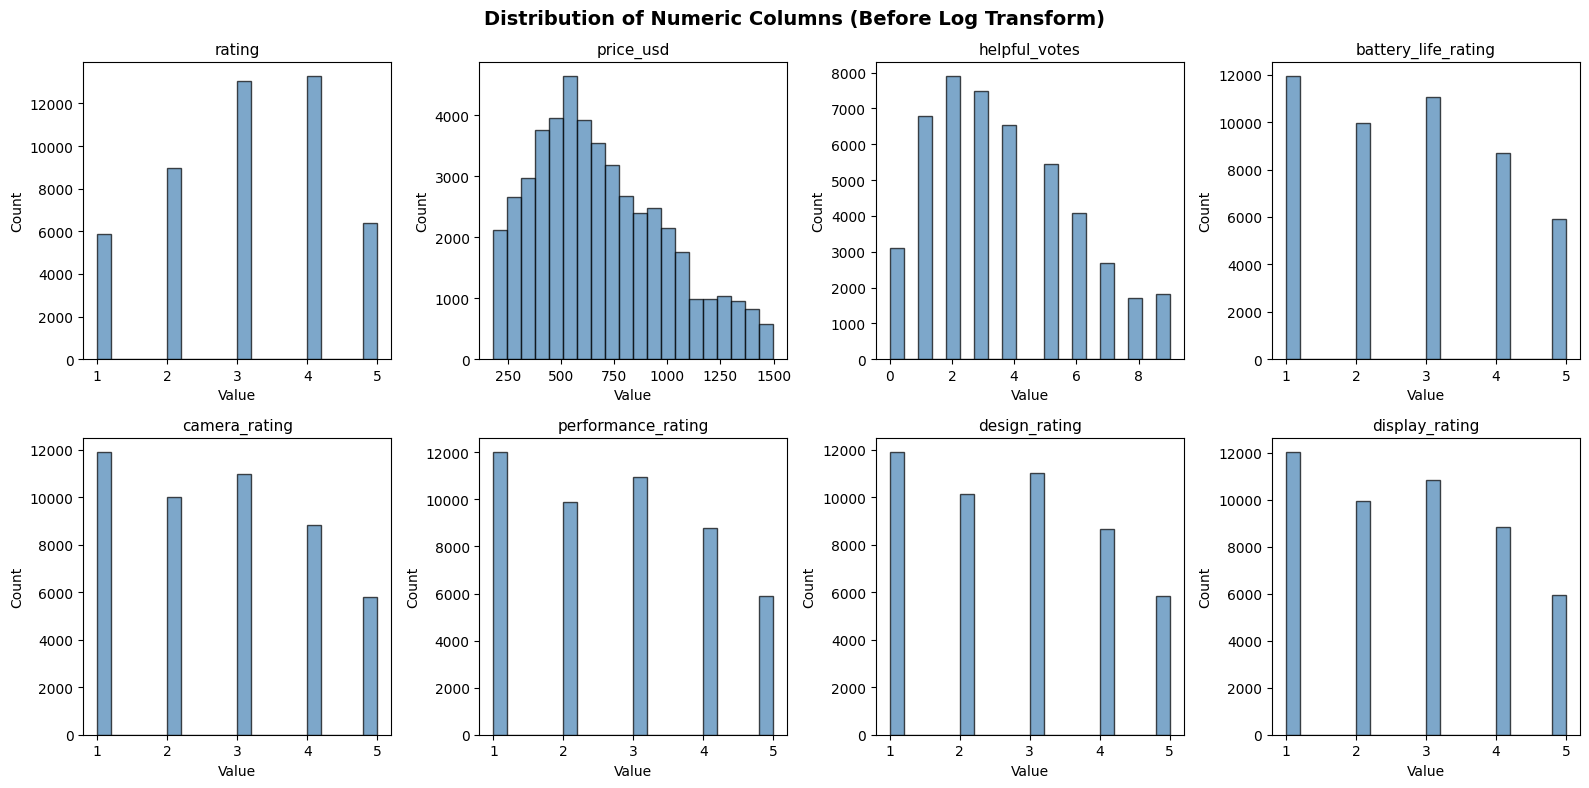

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_cols = ['rating', 'price_usd', 'helpful_votes',
                'battery_life_rating', 'camera_rating',
                'performance_rating', 'design_rating', 'display_rating']

for i, col in enumerate(numeric_cols):
    axes[i].hist(mobile[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numeric Columns (Before Log Transform)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Before log transform:
  Min: $180.02
  Max: $1499.89
  Skewness: 0.5593

After log transform:
  Min: 5.1986
  Max: 7.3138
  Skewness: -0.3369


C:\Users\Saroon\AppData\Local\Temp\ipykernel_12028\1849783943.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Saroon\Desktop\Phython\new_python\Ml Project 2\mobile_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


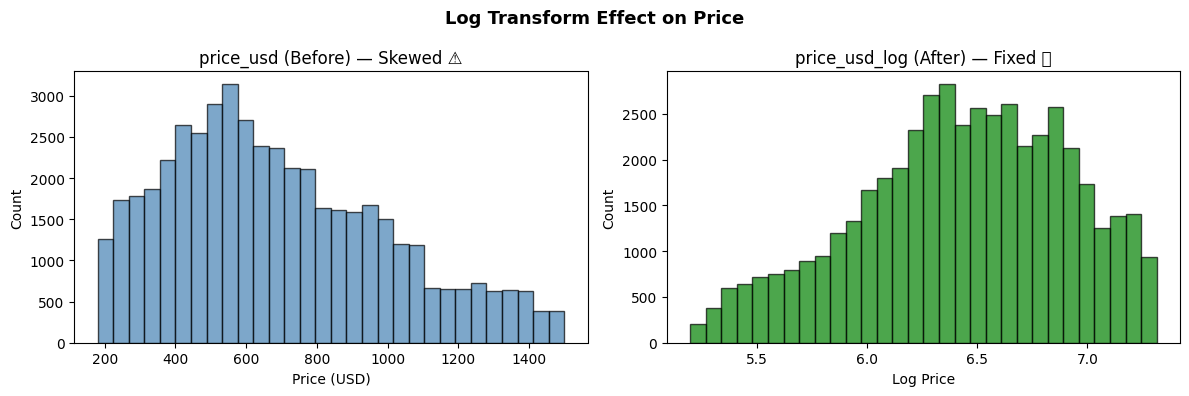

In [38]:
# Log transform price_usd to fix skewness
mobile['price_usd_log'] = np.log1p(mobile['price_usd'])

print("Before log transform:")
print(f"  Min: ${mobile['price_usd'].min():.2f}")
print(f"  Max: ${mobile['price_usd'].max():.2f}")
print(f"  Skewness: {mobile['price_usd'].skew():.4f}")

print("\nAfter log transform:")
print(f"  Min: {mobile['price_usd_log'].min():.4f}")
print(f"  Max: {mobile['price_usd_log'].max():.4f}")
print(f"  Skewness: {mobile['price_usd_log'].skew():.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mobile['price_usd'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('price_usd (Before) — Skewed ⚠️')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')

axes[1].hist(mobile['price_usd_log'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1].set_title('price_usd_log (After) — Fixed ✅')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Count')

plt.suptitle('Log Transform Effect on Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
print(mobile.info())
mobile

<class 'pandas.DataFrame'>
Index: 47550 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   review_id             47550 non-null  int64         
 1   customer_name         47550 non-null  str           
 2   age                   47550 non-null  int64         
 3   brand                 47550 non-null  str           
 4   model                 47550 non-null  str           
 5   price_usd             47550 non-null  float64       
 6   currency              47550 non-null  str           
 7   exchange_rate_to_usd  47550 non-null  float64       
 8   rating                47550 non-null  int64         
 9   sentiment             47550 non-null  str           
 10  country               47550 non-null  str           
 11  language              47550 non-null  str           
 12  review_date           47550 non-null  datetime64[us]
 13  verified_purchase     47550 non-

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,price_usd_log
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2,Negative,...,2023-11-06,True,1,1,3,2,1,1,Amazon,5.823963
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4,Positive,...,2023-03-30,True,3,2,4,3,2,5,Flipkart,5.732629
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4,Positive,...,2022-12-07,True,3,5,3,2,4,8,AliExpress,6.763342
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3,Positive,...,2025-03-11,False,1,3,2,1,2,3,Amazon,6.495175
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3,Neutral,...,2023-09-29,True,3,3,2,2,1,0,BestBuy,6.675987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,AUD,1.53,4,Positive,...,2023-08-17,False,3,3,4,3,5,4,BestBuy,6.267390
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,AUD,1.53,3,Neutral,...,2023-09-23,False,3,2,4,1,3,2,AliExpress,6.816572
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,AED,3.67,4,Positive,...,2023-04-04,True,2,3,4,4,5,4,Amazon,7.052998
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,USD,1.00,3,Positive,...,2025-07-11,True,1,2,2,1,3,6,store,6.131313


# Label encode sentiment


In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Label encode sentiment
mobile['sentiment_encoded'] = le.fit_transform(mobile['sentiment'])

# Label encode verified_purchase
mobile['verified_purchase_encoded'] = le.fit_transform(mobile['verified_purchase'])

# Check result
print("Sentiment encoding:")
print(mobile[['sentiment','sentiment_encoded']].drop_duplicates().sort_values('sentiment_encoded'))

print("\nVerified Purchase encoding:")
print(mobile[['verified_purchase','verified_purchase_encoded']].drop_duplicates().sort_values('verified_purchase_encoded'))

Sentiment encoding:
  sentiment  sentiment_encoded
0  Negative                  0
4   Neutral                  1
1  Positive                  2

Verified Purchase encoding:
   verified_purchase  verified_purchase_encoded
3              False                          0
0               True                          1


# One Hot Encoding for brand, source, country


In [41]:
# One Hot Encoding for brand, source, country
mobile_encoded = pd.get_dummies(mobile, columns=['brand', 'source', 'country'], drop_first=False)

print("Shape before encoding:", mobile.shape)
print("Shape after encoding:", mobile_encoded.shape)

print("\nNew columns added:")
new_cols = [col for col in mobile_encoded.columns if col not in mobile.columns]
print(new_cols)

Shape before encoding: (47550, 24)
Shape after encoding: (47550, 42)

New columns added:
['brand_Apple', 'brand_Google', 'brand_Motorola', 'brand_OnePlus', 'brand_Realme', 'brand_Samsung', 'brand_Xiaomi', 'source_AliExpress', 'source_Amazon', 'source_BestBuy', 'source_Flipkart', 'source_eBay', 'source_store', 'country_Australia', 'country_Brazil', 'country_Canada', 'country_Germany', 'country_India', 'country_UAE', 'country_UK', 'country_USA']


In [42]:
mobile.isnull().sum()

review_id                    0
customer_name                0
age                          0
brand                        0
model                        0
price_usd                    0
currency                     0
exchange_rate_to_usd         0
rating                       0
sentiment                    0
country                      0
language                     0
review_date                  0
verified_purchase            0
battery_life_rating          0
camera_rating                0
performance_rating           0
design_rating                0
display_rating               0
helpful_votes                0
source                       0
price_usd_log                0
sentiment_encoded            0
verified_purchase_encoded    0
dtype: int64

In [43]:
# One Hot Encode model AND language together
mobile_encoded = pd.get_dummies(mobile_encoded, 
                                columns=['model', 'language'], 
                                drop_first=False)

print("New shape:", mobile_encoded.shape)

# Show new columns
model_cols = [col for col in mobile_encoded.columns if col.startswith('model_')]
lang_cols = [col for col in mobile_encoded.columns if col.startswith('language_')]

print("\nModel columns added:", len(model_cols))
print(model_cols)

print("\nLanguage columns added:", len(lang_cols))
print(lang_cols)

New shape: (47550, 66)

Model columns added: 22
['model_Edge 50', 'model_Galaxy A55', 'model_Galaxy Note 20', 'model_Galaxy S24', 'model_Galaxy Z Flip', 'model_Mi 13 Pro', 'model_Moto G Power', 'model_OnePlus 11R', 'model_OnePlus 12', 'model_OnePlus Nord 3', 'model_Pixel 6', 'model_Pixel 7a', 'model_Pixel 8', 'model_Poco X6', 'model_Razr 40', 'model_Realme 12 Pro', 'model_Realme Narzo 70', 'model_Redmi Note 13', 'model_iPhone 13', 'model_iPhone 14', 'model_iPhone 15 Pro', 'model_iPhone SE']

Language columns added: 4
['language_English', 'language_German', 'language_Hindi', 'language_Portuguese']


In [44]:
# Convert True/False to 1/0
bool_cols = mobile_encoded.select_dtypes(include='bool').columns
mobile_encoded[bool_cols] = mobile_encoded[bool_cols].astype(int)
print("Done — True/False converted to 1/0")
print("Total bool columns converted:", len(bool_cols))
mobile_encoded.head(2)

Done — True/False converted to 1/0
Total bool columns converted: 48


,review_id,customer_name,age,price_usd,currency,exchange_rate_to_usd,rating,sentiment,review_date,verified_purchase,...,model_Realme Narzo 70,model_Redmi Note 13,model_iPhone 13,model_iPhone 14,model_iPhone 15 Pro,model_iPhone SE,language_English,language_German,language_Hindi,language_Portuguese
0,1,Aryan Maharaj,45,337.31,INR,83.0,2,Negative,2023-11-06,1,...,0,0,0,0,0,0,0,0,1,0
1,2,Davi Miguel Sousa,18,307.78,BRL,5.7,4,Positive,2023-03-30,1,...,0,0,0,0,0,0,0,0,0,1


In [45]:
print("Final shape:", mobile_encoded.shape)
print("model column still exists?", 'model' in mobile_encoded.columns)
print("language column still exists?", 'language' in mobile_encoded.columns)

Final shape: (47550, 66)
model column still exists? False
language column still exists? False


## running the elbo method 

## 2ndd try 

In [46]:
from sklearn.preprocessing import StandardScaler

# Mentor's 14 features — mapped to encoded versions
cluster_features = [
    # Numeric — directly usable
    'age',
    'price_usd_log',           # price_usd → log transformed
    'rating',
    'battery_life_rating',
    'camera_rating',
    'performance_rating',
    'design_rating',
    'display_rating',
    'helpful_votes',
    # Encoded versions
    'sentiment_encoded',        # sentiment → encoded
    'verified_purchase_encoded',# verified_purchase → encoded
    # Brand one hot (brand → 7 columns)
    'brand_Apple', 'brand_Google', 'brand_Motorola',
    'brand_OnePlus', 'brand_Realme', 'brand_Samsung', 'brand_Xiaomi',
    # Model one hot (model → 22 columns)
    'model_Edge 50', 'model_Galaxy A55', 'model_Galaxy Note 20',
    'model_Galaxy S24', 'model_Galaxy Z Flip',
    'model_iPhone 13', 'model_iPhone 14',
    'model_iPhone 15 Pro', 'model_iPhone SE',
    'model_Mi 13 Pro', 'model_Moto G Power',
    'model_OnePlus 11R', 'model_OnePlus 12', 'model_OnePlus Nord 3',
    'model_Pixel 6', 'model_Pixel 7a', 'model_Pixel 8',
    'model_Poco X6', 'model_Razr 40',
    'model_Realme 12 Pro', 'model_Realme Narzo 70',
    'model_Redmi Note 13',
    # Country one hot (country → 8 columns)
    'country_Australia', 'country_Brazil', 'country_Canada',
    'country_Germany', 'country_India', 'country_UAE',
    'country_UK', 'country_USA'
]

print("Total features:", len(cluster_features))

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(mobile_encoded[cluster_features])

print("Shape of scaled data:", cluster_scaled.shape)
print("Mean (should be ~0):", cluster_scaled.mean(axis=0).round(2))
print("Std (should be ~1):", cluster_scaled.std(axis=0).round(2))

Total features: 48
Shape of scaled data: (47550, 48)
Mean (should be ~0): [ 0.  0.  0.  0. -0. -0.  0.  0. -0.  0. -0.  0.  0.  0.  0.  0.  0. -0.
  0.  0.  0.  0. -0. -0. -0.  0.  0.  0. -0.  0.  0. -0. -0. -0. -0.  0.
 -0.  0.  0. -0.  0.  0.  0. -0.  0. -0. -0.  0.]
Std (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Inertia values:
K=1: 2282400.00
K=2: 2101866.63
K=3: 2012311.01
K=4: 1925760.51
K=5: 1844888.60
K=6: 1737855.30
K=7: 1622279.95
K=8: 1571063.51
K=9: 1521094.82
K=10: 1471096.67


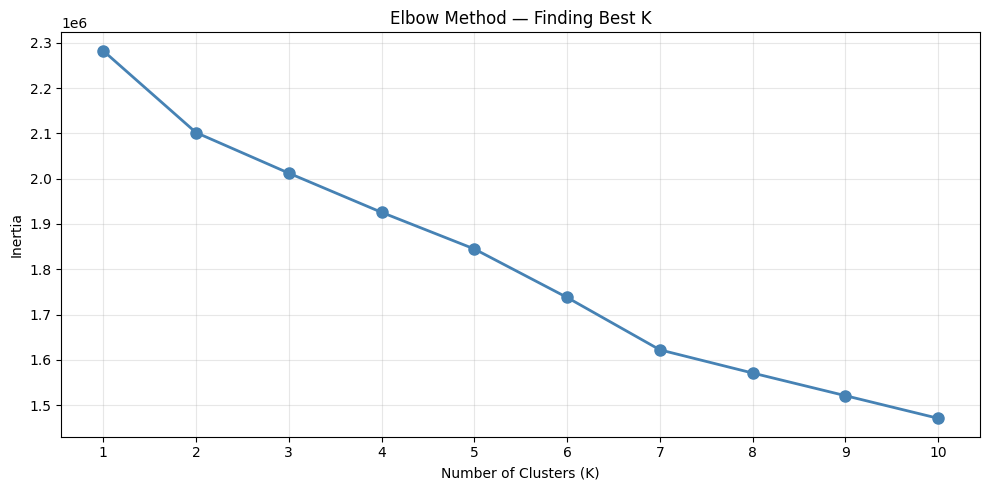

In [47]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, val in zip(k_range, inertia):
    print(f"K={k}: {val:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue',
         linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3rd trial 

## 3rd trial lable encoding and got correct elbow 

Total features: 14
Shape: (47550, 14)

Inertia values:
K=1: 665700.00
K=2: 485202.37
K=3: 451029.45
K=4: 424945.22
K=5: 405010.08
K=6: 386972.20
K=7: 375047.38
K=8: 362564.76
K=9: 355450.21
K=10: 344309.05


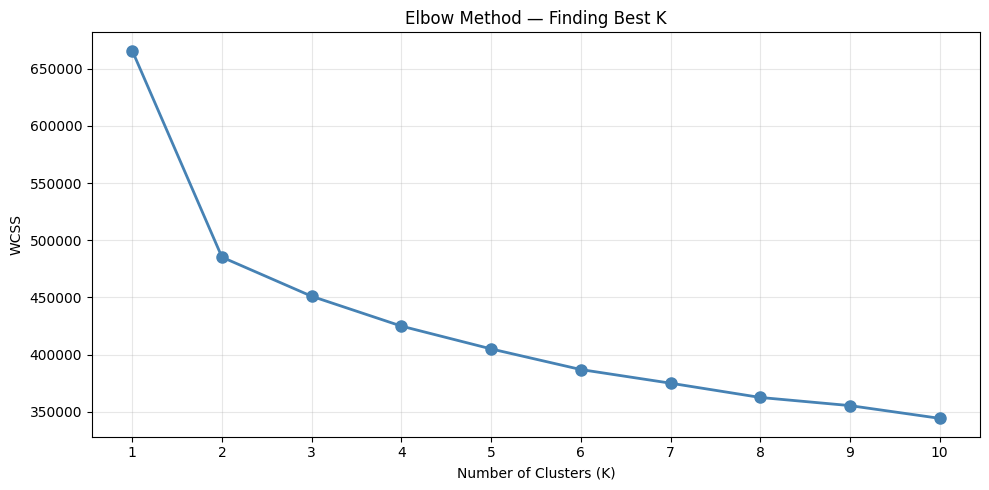

In [48]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

# Step 1 — Label encode the text columns
le = LabelEncoder()
mobile['sentiment_enc']  = le.fit_transform(mobile['sentiment'])
mobile['verified_enc']   = le.fit_transform(mobile['verified_purchase'])
mobile['brand_enc']      = le.fit_transform(mobile['brand'])
mobile['model_enc']      = le.fit_transform(mobile['model'])
mobile['country_enc']    = le.fit_transform(mobile['country'])

# Step 2 — Select exactly 14 features (mentor's list)
cluster_features = [
    'age',
    'price_usd_log',      # price_usd → log transformed
    'rating',
    'battery_life_rating',
    'camera_rating',
    'performance_rating',
    'design_rating',
    'display_rating',
    'helpful_votes',
    'sentiment_enc',       # sentiment → encoded
    'verified_enc',        # verified_purchase → encoded
    'brand_enc',           # brand → encoded
    'model_enc',           # model → encoded
    'country_enc'          # country → encoded
]

print("Total features:", len(cluster_features))

# Step 3 — Scale
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(mobile[cluster_features])

print("Shape:", cluster_scaled.shape)

# Step 4 — Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

print("\nInertia values:")
for k, val in zip(k_range, inertia):
    print(f"K={k}: {val:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue',
         linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import silhouette_score

print("K | Silhouette Score")
print("-" * 25)
for k in range(2, 9):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = kmeans_test.fit_predict(cluster_scaled)
    sil = silhouette_score(cluster_scaled, labels_test,
                           sample_size=10000, random_state=42)
    print(f"K={k} | {sil:.4f}")

K | Silhouette Score
-------------------------
K=2 | 0.2338
K=3 | 0.1337
K=4 | 0.1302
K=5 | 0.1069
K=6 | 0.1125
K=7 | 0.1069
K=8 | 0.1074


## Training the model 

In [50]:
# Train final K-Means model with K=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
mobile['cluster'] = kmeans_final.fit_predict(cluster_scaled)

print("Cluster sizes:")
print(mobile['cluster'].value_counts())

print("\nCluster profiles:")
print(mobile.groupby('cluster').agg(
    avg_price  = ('price_usd', 'mean'),
    avg_rating = ('rating',    'mean'),
    size       = ('price_usd', 'count')
).round(2))

Cluster sizes:
cluster
1    25533
0    22017
Name: count, dtype: int64

Cluster profiles:
         avg_price  avg_rating   size
cluster                              
0           689.68        2.07  22017
1           690.08        4.01  25533


In [51]:
mobile

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,source,price_usd_log,sentiment_encoded,verified_purchase_encoded,sentiment_enc,verified_enc,brand_enc,model_enc,country_enc,cluster
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2,Negative,...,Amazon,5.823963,0,1,0,1,4,15,4,0
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4,Positive,...,Flipkart,5.732629,2,1,2,1,4,15,1,1
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4,Positive,...,AliExpress,6.763342,2,1,2,1,1,10,4,1
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3,Positive,...,Amazon,6.495175,2,0,2,0,6,17,5,0
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3,Neutral,...,BestBuy,6.675987,1,1,1,1,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,AUD,1.53,4,Positive,...,BestBuy,6.267390,2,0,2,0,4,15,0,1
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,AUD,1.53,3,Neutral,...,AliExpress,6.816572,1,0,1,0,5,2,0,0
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,AED,3.67,4,Positive,...,Amazon,7.052998,2,1,2,1,0,21,5,1
49998,49999,Robert Morris,31,Realme,Realme Narzo 70,459.04,USD,1.00,3,Positive,...,store,6.131313,2,1,2,1,4,16,7,0


In [52]:
# Cluster 0 Customers
cluster0 = mobile[mobile['cluster'] == 0]
cluster0.to_csv('model_files/cluster0.csv', index=False)
print(f"✅ Cluster 0 saved — {len(cluster0)} rows")

# Cluster 1 Customers
cluster1 = mobile[mobile['cluster'] == 1]
cluster1.to_csv('model_files/cluster1.csv', index=False)
print(f"✅ Cluster 1 saved — {len(cluster1)} rows")

# Verify
print("\nCluster 0 sample:")
print(cluster0.head(3))

print("\nCluster 1 sample:")
print(cluster1.head(3))

✅ Cluster 0 saved — 22017 rows
✅ Cluster 1 saved — 25533 rows

Cluster 0 sample:
   review_id  customer_name  age     brand          model  price_usd currency  \
0          1  Aryan Maharaj   45    Realme  Realme 12 Pro     337.31      INR   
3          4   David Guzman   19    Xiaomi  Redmi Note 13     660.94      AED   
4          5      Yago Leão   38  Motorola        Edge 50     792.13      BRL   

   exchange_rate_to_usd  rating sentiment  ...   source price_usd_log  \
0                 83.00       2  Negative  ...   Amazon      5.823963   
3                  3.67       3  Positive  ...   Amazon      6.495175   
4                  5.70       3   Neutral  ...  BestBuy      6.675987   

  sentiment_encoded  verified_purchase_encoded  sentiment_enc  verified_enc  \
0                 0                          1              0             1   
3                 2                          0              2             0   
4                 1                          1              1   

In [53]:
cluster0

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,source,price_usd_log,sentiment_encoded,verified_purchase_encoded,sentiment_enc,verified_enc,brand_enc,model_enc,country_enc,cluster
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,INR,83.00,2,Negative,...,Amazon,5.823963,0,1,0,1,4,15,4,0
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,AED,3.67,3,Positive,...,Amazon,6.495175,2,0,2,0,6,17,5,0
4,5,Yago Leão,38,Motorola,Edge 50,792.13,BRL,5.70,3,Neutral,...,BestBuy,6.675987,1,1,1,1,2,0,1,0
6,7,Gina Moore,40,OnePlus,OnePlus 12,420.13,AED,3.67,3,Positive,...,eBay,6.042942,2,0,2,0,3,8,5,0
7,8,James Howard,39,Apple,iPhone SE,1443.76,AUD,1.53,2,Negative,...,Amazon,7.275698,0,1,0,1,0,21,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49981,49982,David Alexander,23,OnePlus,OnePlus 12,722.84,CAD,1.38,3,Positive,...,Flipkart,6.584570,2,1,2,1,3,8,2,0
49989,49990,Donald Huff,23,Google,Pixel 7a,783.74,AED,3.67,2,Neutral,...,AliExpress,6.665352,1,1,1,1,1,11,5,0
49992,49993,Felipe Mendes,28,Google,Pixel 8,946.54,BRL,5.70,1,Negative,...,Amazon,6.853869,0,1,0,1,1,12,1,0
49996,49997,Dr. Tiffany Patterson,28,Samsung,Galaxy Note 20,911.85,AUD,1.53,3,Neutral,...,AliExpress,6.816572,1,0,1,0,5,2,0,0


In [54]:
cluster1

,review_id,customer_name,age,brand,model,price_usd,currency,exchange_rate_to_usd,rating,sentiment,...,source,price_usd_log,sentiment_encoded,verified_purchase_encoded,sentiment_enc,verified_enc,brand_enc,model_enc,country_enc,cluster
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,BRL,5.70,4,Positive,...,Flipkart,5.732629,2,1,2,1,4,15,1,1
2,3,Pahal Balay,27,Google,Pixel 6,864.53,INR,83.00,4,Positive,...,AliExpress,6.763342,2,1,2,1,1,10,4,1
5,6,Lara Abreu,38,Apple,iPhone 14,948.79,BRL,5.70,5,Positive,...,AliExpress,6.856241,2,0,2,0,0,19,1,1
8,9,Rosalia Beyer,32,Realme,Realme 12 Pro,275.73,EUR,0.93,4,Positive,...,eBay,5.623042,2,0,2,0,4,15,3,1
9,10,Valerie Gray,31,OnePlus,OnePlus Nord 3,545.57,AUD,1.53,3,Positive,...,BestBuy,6.303662,2,1,2,1,3,9,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49993,49994,Shawn Mueller,47,Google,Pixel 7a,949.60,CAD,1.38,5,Positive,...,store,6.857093,2,1,2,1,1,11,2,1
49994,49995,Netra Srinivas,26,Xiaomi,Poco X6,300.72,INR,83.00,5,Positive,...,eBay,5.709499,2,1,2,1,6,13,4,1
49995,49996,Rebecca Pratt,18,Realme,Realme 12 Pro,526.10,AUD,1.53,4,Positive,...,BestBuy,6.267390,2,0,2,0,4,15,0,1
49997,49998,Alexandra Singh,21,Apple,iPhone SE,1155.32,AED,3.67,4,Positive,...,Amazon,7.052998,2,1,2,1,0,21,5,1


In [55]:
cluster0.shape

(22017, 30)

In [56]:
cluster1.shape

(25533, 30)

## rating distrubtiommn 

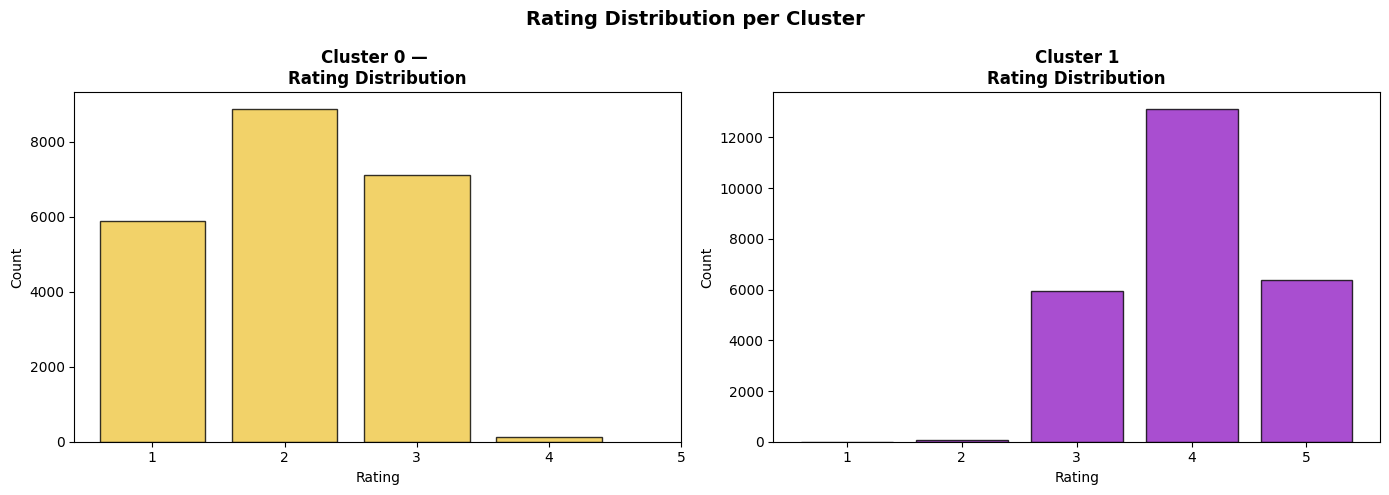

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (cluster_df, name, color) in enumerate([
    (cluster0, 'Cluster 0 — ', "#efc744"),
    (cluster1, 'Cluster 1', "#9422c5")
]):
    rating_counts = cluster_df['rating'].value_counts().sort_index()
    axes[i].bar(rating_counts.index, rating_counts.values,
                color=color, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{name}\nRating Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Rating')
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([1,2,3,4,5])

plt.suptitle('Rating Distribution per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## cluster 0 has high rebview in 123 rating 
## and cluster 1 has 3 avarage and 45 hihj rating 

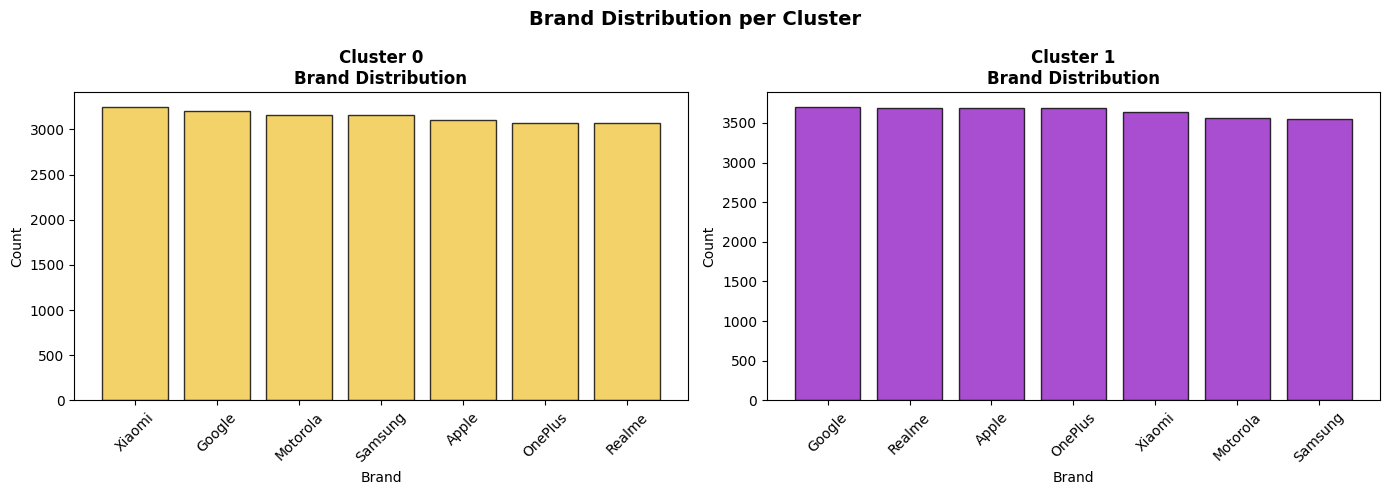

In [58]:
# Cell 86 — Brand Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (cluster_df, name, color) in enumerate([
    (cluster0, 'Cluster 0', "#efc744"),
    (cluster1, 'Cluster 1', "#9422c5")
]):
    brand_counts = cluster_df['brand'].value_counts()
    axes[i].bar(brand_counts.index, brand_counts.values,
                color=color, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'{name}\nBrand Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Brand')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Brand Distribution per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

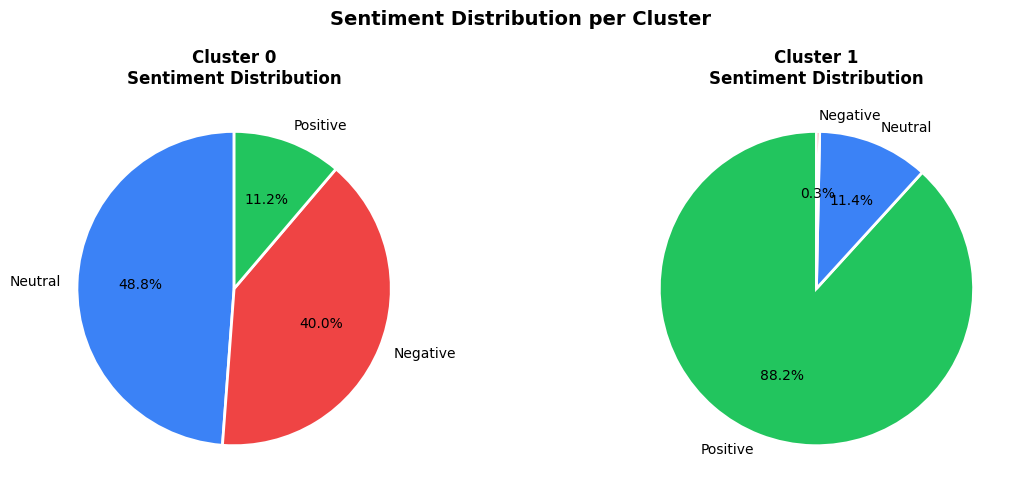

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fixed color mapping — each sentiment gets its correct color
sentiment_colors = {
    'Positive': '#22c55e',  # Green
    'Neutral':  '#3b82f6',  # Blue
    'Negative': '#ef4444'   # Red
}

for i, (cluster_df, name) in enumerate([
    (cluster0, 'Cluster 0'),
    (cluster1, 'Cluster 1')
]):
    sentiment_counts = cluster_df['sentiment'].value_counts()
    colors_ordered = [sentiment_colors[s] for s in sentiment_counts.index]

    axes[i].pie(sentiment_counts.values,
                labels=sentiment_counts.index,
                autopct='%1.1f%%',
                colors=colors_ordered,
                startangle=90,
                wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[i].set_title(f'{name}\nSentiment Distribution',
                      fontsize=12, fontweight='bold')

plt.suptitle('Sentiment Distribution per Cluster',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## cluster0 has high negative  and nutural
## Cluster1 has high nutral and postive 

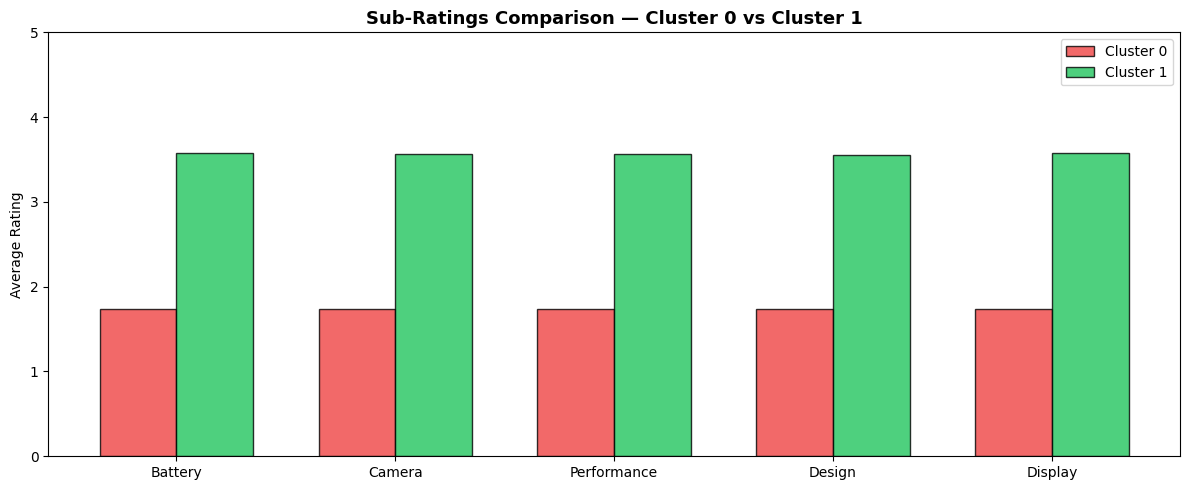

In [60]:
# Cell 89 — Sub Ratings Comparison
sub_ratings = ['battery_life_rating', 'camera_rating',
               'performance_rating', 'design_rating', 'display_rating']
c0_means = cluster0[sub_ratings].mean()
c1_means = cluster1[sub_ratings].mean()
x = np.arange(len(sub_ratings))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, c0_means, width, label='Cluster 0',
       color='#ef4444', alpha=0.8, edgecolor='black')
ax.bar(x + width/2, c1_means, width, label='Cluster 1',
       color='#22c55e', alpha=0.8, edgecolor='black')
ax.set_title('Sub-Ratings Comparison — Cluster 0 vs Cluster 1',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Battery', 'Camera', 'Performance', 'Design', 'Display'])
ax.set_ylabel('Average Rating')
ax.set_ylim(0, 5)
ax.legend()
plt.tight_layout()
plt.show()

# conclusion is  clustor 0 is having negative impact and cvlustor 1 has postive impact 


Using partial hybrid  recomandation 

In [61]:
from sklearn.metrics.pairwise import cosine_similarity

# Step 1 — Build enhanced product table with behavior signals
product_df = mobile.groupby(['brand', 'model']).agg(
    avg_price            = ('price_usd',                 'median'),
    avg_rating           = ('rating',                    'mean'),
    avg_battery          = ('battery_life_rating',       'mean'),
    avg_camera           = ('camera_rating',             'mean'),
    avg_performance      = ('performance_rating',        'mean'),
    avg_design           = ('design_rating',             'mean'),
    avg_display          = ('display_rating',            'mean'),
    num_reviews          = ('review_id',                 'count'),
    avg_helpful_votes    = ('helpful_votes',             'mean'),
    positive_review_rate = ('sentiment_encoded',         'mean'),
    verified_rate        = ('verified_purchase_encoded', 'mean')
).reset_index()

# Step 2 — Add USD-only price (actual US market price)
usd_prices = mobile[mobile['currency'] == 'USD'].groupby('model')['price_usd'].median()
product_df['usd_price'] = product_df['model'].map(usd_prices)
product_df['usd_price'] = product_df['usd_price'].fillna(product_df['avg_price'])
product_df['usd_price'] = product_df['usd_price'].round(0).astype(int)

print("Product table shape:", product_df.shape)
print("\nPrice check — avg vs USD price:")
print(product_df[['brand', 'model', 'avg_price', 'usd_price']].to_string())

Product table shape: (22, 14)

Price check — avg vs USD price:
       brand            model  avg_price  usd_price
0      Apple        iPhone 13   1106.380       1095
1      Apple        iPhone 14   1094.510       1100
2      Apple    iPhone 15 Pro   1102.270       1077
3      Apple        iPhone SE   1101.030       1117
4     Google          Pixel 6    808.530        817
5     Google         Pixel 7a    809.440        827
6     Google          Pixel 8    799.520        768
7   Motorola          Edge 50    514.920        544
8   Motorola     Moto G Power    505.340        481
9   Motorola          Razr 40    511.440        519
10   OnePlus      OnePlus 11R    667.025        676
11   OnePlus       OnePlus 12    668.090        681
12   OnePlus   OnePlus Nord 3    669.400        669
13    Realme    Realme 12 Pro    396.410        413
14    Realme  Realme Narzo 70    392.820        410
15   Samsung       Galaxy A55    908.740        884
16   Samsung   Galaxy Note 20    905.775        889
1

In [62]:
product_df.shape

(22, 14)

In [63]:
# Step 2 — One hot encode brand
product_encoded = pd.get_dummies(product_df, columns=['brand'])

# Step 3 — Log transform price
product_encoded['avg_price_log'] = np.log1p(product_encoded['avg_price'])

# Step 4 — Select ALL features (content + behavior)
sim_features = [
    # Content features
    'avg_price_log', 'avg_rating',
    'avg_battery', 'avg_camera',
    'avg_performance', 'avg_design', 'avg_display',
    # Behavior signals
    'positive_review_rate', 'verified_rate',
    'avg_helpful_votes', 'num_reviews',
    # Brand one hot
] + [col for col in product_encoded.columns if col.startswith('brand_')]

print("Features used:")
print(sim_features)
print("\nTotal features:", len(sim_features))

# Step 5 — Scale
scaler2 = StandardScaler()
product_scaled = scaler2.fit_transform(product_encoded[sim_features])

# Step 6 — Build 22x22 similarity matrix
similarity_matrix = cosine_similarity(product_scaled)

print("\nSimilarity matrix shape:", similarity_matrix.shape)

# Show sample scores for iPhone 13
print("\nSample — iPhone 13 similarity scores:")
for i, score in enumerate(similarity_matrix[0]):
    print(f"  vs {product_df.iloc[i]['model']}: {score:.3f}")

Features used:
['avg_price_log', 'avg_rating', 'avg_battery', 'avg_camera', 'avg_performance', 'avg_design', 'avg_display', 'positive_review_rate', 'verified_rate', 'avg_helpful_votes', 'num_reviews', 'brand_Apple', 'brand_Google', 'brand_Motorola', 'brand_OnePlus', 'brand_Realme', 'brand_Samsung', 'brand_Xiaomi']

Total features: 18

Similarity matrix shape: (22, 22)

Sample — iPhone 13 similarity scores:
  vs iPhone 13: 1.000
  vs iPhone 14: 0.749
  vs iPhone 15 Pro: -0.263
  vs iPhone SE: 0.186
  vs Pixel 6: 0.130
  vs Pixel 7a: 0.124
  vs Pixel 8: 0.030
  vs Edge 50: -0.591
  vs Moto G Power: -0.240
  vs Razr 40: -0.298
  vs OnePlus 11R: -0.270
  vs OnePlus 12: 0.352
  vs OnePlus Nord 3: 0.208
  vs Realme 12 Pro: 0.224
  vs Realme Narzo 70: -0.248
  vs Galaxy A55: -0.384
  vs Galaxy Note 20: 0.489
  vs Galaxy S24: -0.593
  vs Galaxy Z Flip: 0.330
  vs Mi 13 Pro: -0.596
  vs Poco X6: -0.168
  vs Redmi Note 13: -0.379


## Recommendation function

In [64]:
# Price weighted similarity matrix
product_encoded2 = pd.get_dummies(product_df, columns=['brand'])
product_encoded2['avg_price_log'] = np.log1p(product_encoded2['avg_price'])

price_col    = product_encoded2['avg_price_log'].values.reshape(-1,1)
rating_col   = product_encoded2['avg_rating'].values.reshape(-1,1)
battery_col  = product_encoded2['avg_battery'].values.reshape(-1,1)
camera_col   = product_encoded2['avg_camera'].values.reshape(-1,1)
perf_col     = product_encoded2['avg_performance'].values.reshape(-1,1)
design_col   = product_encoded2['avg_design'].values.reshape(-1,1)
display_col  = product_encoded2['avg_display'].values.reshape(-1,1)
pos_col      = product_encoded2['positive_review_rate'].values.reshape(-1,1)
ver_col      = product_encoded2['verified_rate'].values.reshape(-1,1)
help_col     = product_encoded2['avg_helpful_votes'].values.reshape(-1,1)
rev_col      = product_encoded2['num_reviews'].values.reshape(-1,1)
brand_cols   = product_encoded2[
    [col for col in product_encoded2.columns if col.startswith('brand_')]].values

product_array = np.hstack([
    price_col, price_col, price_col,
    rating_col, battery_col, camera_col,
    perf_col, design_col, display_col,
    pos_col, ver_col, help_col, rev_col,
    brand_cols
])

scaler3 = StandardScaler()
product_scaled2 = scaler3.fit_transform(product_array)
similarity_matrix2 = cosine_similarity(product_scaled2)

print("Feature array shape:", product_array.shape)
print("Similarity matrix shape:", similarity_matrix2.shape)

Feature array shape: (22, 20)
Similarity matrix shape: (22, 22)


## saving the pickle file for K mean clustring 

In [65]:
import pickle
import os

os.makedirs('model_files', exist_ok=True)

# Save K-Means model
pickle.dump(kmeans_final, open('model_files/kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('model_files/scaler.pkl', 'wb'))
print("✅ kmeans_model.pkl saved")
print("✅ scaler.pkl saved")

# Save recommendation system
pickle.dump(similarity_matrix2, open('model_files/similarity_matrix.pkl', 'wb'))
print("✅ similarity_matrix.pkl saved")

# Save product data (now includes usd_price column)
product_df.to_csv('model_files/product_data.csv', index=False)
print("✅ product_data.csv saved  ← now has usd_price column")

# Save review data with cluster labels
review_df_save = mobile[['brand', 'model', 'price_usd', 'rating', 'sentiment',
                          'battery_life_rating', 'camera_rating', 'performance_rating',
                          'design_rating', 'display_rating', 'helpful_votes',
                          'cluster', 'age', 'country', 'verified_purchase', 'source']]
review_df_save.to_csv('model_files/mobile_clustered.csv', index=False)
print("✅ mobile_clustered.csv saved")

print("\n✅ All files in model_files:")
for f in os.listdir('model_files'):
    size = os.path.getsize(f'model_files/{f}')
    print(f"  {f}  ({size/1024:.1f} KB)")

# Confirm usd_price is in the saved file
check = pd.read_csv('model_files/product_data.csv')
print("\n✅ Columns in product_data.csv:", check.columns.tolist())
print("\nPrice check:")
print(check[['brand', 'model', 'avg_price', 'usd_price']].to_string())

✅ kmeans_model.pkl saved
✅ scaler.pkl saved
✅ similarity_matrix.pkl saved
✅ product_data.csv saved  ← now has usd_price column
✅ mobile_clustered.csv saved

✅ All files in model_files:
  cluster0.csv  (3334.5 KB)
  cluster1.csv  (3877.6 KB)
  kmeans_model.pkl  (186.6 KB)
  mobile_clustered.csv  (3430.0 KB)
  product_data.csv  (4.6 KB)
  rec_scaler.pkl  (0.9 KB)
  scaler.pkl  (1.0 KB)
  similarity_matrix.pkl  (3.9 KB)

✅ Columns in product_data.csv: ['brand', 'model', 'avg_price', 'avg_rating', 'avg_battery', 'avg_camera', 'avg_performance', 'avg_design', 'avg_display', 'num_reviews', 'avg_helpful_votes', 'positive_review_rate', 'verified_rate', 'usd_price']

Price check:
       brand            model  avg_price  usd_price
0      Apple        iPhone 13   1106.380       1095
1      Apple        iPhone 14   1094.510       1100
2      Apple    iPhone 15 Pro   1102.270       1077
3      Apple        iPhone SE   1101.030       1117
4     Google          Pixel 6    808.530        817
5     Go

In [66]:
# Check brand, price and rating in the dataset
print("=" * 50)
print("BRANDS:")
print(mobile['brand'].value_counts())

print("\n" + "=" * 50)
print("PRICE (price_usd):")
print(mobile['price_usd'].describe().round(2))

print("\n" + "=" * 50)
print("RATING:")
print(mobile['rating'].value_counts().sort_index())
print("\nRating range:", mobile['rating'].min(), "to", mobile['rating'].max())
print("Avg rating:", mobile['rating'].mean().round(2))

print("\n" + "=" * 50)
print("PRICE BY BRAND (avg):")
mobile.groupby('brand')['price_usd'].mean().sort_values(ascending=False).round(2)

print("\n" + "=" * 50)
print("RATING BY BRAND (avg):")
mobile.groupby('brand')['rating'].mean().sort_values(ascending=False).round(2)
mobile.groupby('brand')['price_usd'].mean().sort_values(ascending=False).round(2)


BRANDS:
brand
Google      6903
Xiaomi      6894
Apple       6792
Realme      6763
OnePlus     6759
Motorola    6729
Samsung     6710
Name: count, dtype: int64

PRICE (price_usd):
count    47550.00
mean       689.89
std        310.33
min        180.02
25%        450.76
50%        637.58
75%        901.46
max       1499.89
Name: price_usd, dtype: float64

RATING:
rating
1     5886
2     8961
3    13057
4    13264
5     6382
Name: count, dtype: int64

Rating range: 1 to 5
Avg rating: 3.11

PRICE BY BRAND (avg):

RATING BY BRAND (avg):


brand
Apple       1103.15
Samsung      900.50
Google       805.13
OnePlus      672.16
Motorola     506.54
Xiaomi       449.75
Realme       393.23
Name: price_usd, dtype: float64

In [67]:
print("Min Price: $", mobile['price_usd'])
print("Max Price: $", mobile['price_usd'].max().round(2))

# Price by brand
mobile.groupby('brand')['price_usd'].agg(['min','max','mean']).round(2)

Min Price: $ 0         337.31
1         307.78
2         864.53
3         660.94
4         792.13
          ...   
49995     526.10
49996     911.85
49997    1155.32
49998     459.04
49999     380.16
Name: price_usd, Length: 47550, dtype: float64
Max Price: $ 1499.89


,min,max,mean
brand,,,
Apple,700.01,1499.89,1103.15
Google,500.05,1099.98,805.13
Motorola,200.01,799.99,506.54
OnePlus,350.01,999.90,672.16
Realme,180.02,599.94,393.23
Samsung,400.71,1399.70,900.50
Xiaomi,200.14,699.96,449.75


In [68]:
mobile.groupby('model')['price_usd'].agg(['min','max','mean','count']).round(2)

,min,max,mean,count
model,,,,
Edge 50,200.09,799.99,509.78,2213
Galaxy A55,400.73,1399.70,906.95,1703
Galaxy Note 20,401.11,1399.51,900.87,1700
Galaxy S24,401.20,1399.14,895.13,1674
Galaxy Z Flip,400.71,1398.49,898.91,1633
Mi 13 Pro,200.17,699.75,449.18,2318
Moto G Power,200.01,799.91,503.96,2228
OnePlus 11R,350.01,999.56,673.02,2310
OnePlus 12,350.54,999.32,670.24,2200
